In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer

cancer= load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    cancer.data,cancer.target,random_state=0
)

print("="*50)
print("乳腺癌数据集")
print("="*50)
print(f"训练集大小:{X_train.shape[0]}个样本")
print(f"测试集大小:{X_test.shape[0]}个样本")
print(f'特征数量:{X_train.shape[1]}个')

乳腺癌数据集
训练集大小:426个样本
测试集大小:143个样本
特征数量:30个


In [3]:
gbrt =GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train,y_train)

print("="*50)
print("梯度提升决策树")
print("="*50)
print(f"训练集精度:{gbrt.score(X_train,y_train):.3f}")
print(f"测试集精度:{gbrt.score(X_test,y_test):.3f}")


梯度提升决策树
训练集精度:1.000
测试集精度:0.965


In [4]:
gbrt_shallow = GradientBoostingClassifier(max_depth=1,random_state=0)
gbrt_shallow.fit(X_train,y_train)

print("="*50)
print("梯度提升")
print("="*50)
print(f"训练集精度：{gbrt_shallow.score(X_train,y_train):.3f}")
print(f"测试集精度：{gbrt_shallow.score(X_test,y_test):.3f}")

梯度提升
训练集精度：0.991
测试集精度：0.972


In [7]:
gbrt_slow = GradientBoostingClassifier(learning_rate=0.01,n_estimators=1000,random_state=0)
gbrt_slow.fit(X_train,y_train)

print("="*50)
print("梯度提升(learning_rate=0.01,低学习率)")
print(f"训练集精度：{gbrt_slow.score(X_train,y_train):.3f}")
print(f"测试集精度:{gbrt_slow.score(X_test,y_test):.3f}")

梯度提升(learning_rate=0.01,低学习率)
训练集精度：1.000
测试集精度:0.958


In [11]:
print("="*50)
print("不同参数组合对比")
print("="*50)
print(f"{'参数':<30}{'训练集精度':<12}{'测试集精度':<12}")
print("-"*50)

gbrt_default = GradientBoostingClassifier(random_state=0)
gbrt_default.fit(X_train,y_train)
print(f"{'默认(n=100,lr=0.1)':<30}{gbrt_default.score(X_train,y_train):<12.3f}{gbrt_default.score(X_test,y_test):<12.3f}")

gbrt_depth1 = GradientBoostingClassifier(max_depth=1,random_state=0)
gbrt_depth1.fit(X_train,y_train)
print(f"{'max_depth=1':<30}{gbrt_depth1.score(X_train,y_train):<12.3f}{gbrt_depth1.score(X_test,y_test):<12.3f}")

gbrt_low_lr = GradientBoostingClassifier(learning_rate=0.01,n_estimators=1000,random_state=0)
gbrt_low_lr.fit(X_train,y_train)
print(f"{'lr=0.01,n=1000':<30}{gbrt_low_lr.score(X_train,y_train):<12.3f}{gbrt_low_lr.score(X_test,y_test):<12.3f}")

gbrt_best = GradientBoostingClassifier(max_depth=1,learning_rate=0.01,n_estimators=1000,random_state=0)
gbrt_best.fit(X_train,y_train)
print(f"{'max_dpth=1+lr=0.01+n=1000':<30}{gbrt_best.score(X_train,y_train):<12.3f}{gbrt_best.score(X_test,y_test):<12.3f}")

不同参数组合对比
参数                            训练集精度       测试集精度       
--------------------------------------------------
默认(n=100,lr=0.1)              1.000       0.965       
max_depth=1                   0.991       0.972       
lr=0.01,n=1000                1.000       0.958       
max_dpth=1+lr=0.01+n=1000     0.991       0.965       


梯度提升特征重要性（前十个）
1.worst perimeter:0.3477
2.mean concave points:0.2637
3.worst concave points:0.2269
4.worst area:0.0646
5.worst radius:0.0166
6.worst texture:0.0165
7.area error:0.0162
8.mean texture:0.0093
9.mean concavity:0.0092
10.worst smoothness:0.0066


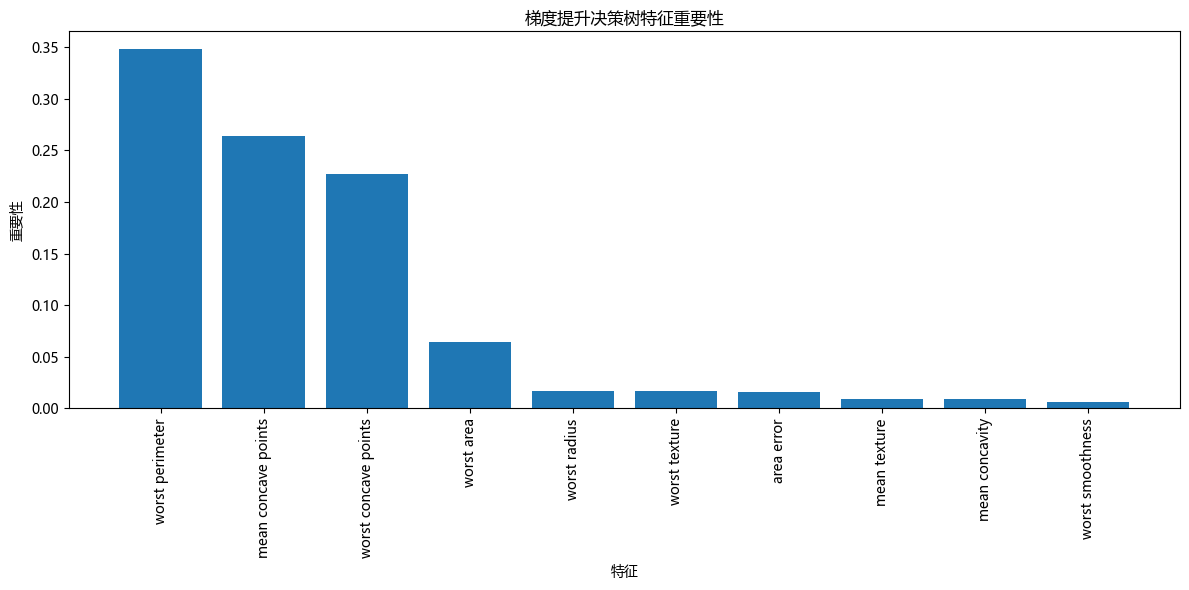

In [13]:
importances = gbrt_best.feature_importances_
indices = np.argsort(importances)[::-1]

print("="*50)
print("梯度提升特征重要性（前十个）")
print("="*50)
for i in range(10):
    print(f"{i+1}.{cancer.feature_names[indices[i]]}:{importances[indices[i]]:.4f}")

plt.figure(figsize=(12,6))
plt.bar(range(10),importances[indices[:10]])
plt.xticks(range(10),[cancer.feature_names[i] for i in indices[:10]],rotation=90)
plt.xlabel('特征')
plt.ylabel('重要性')
plt.title('梯度提升决策树特征重要性')
plt.tight_layout()
plt.show()

半月形数据集上的梯度提升
训练集精度:1.000
测试集精度:0.920


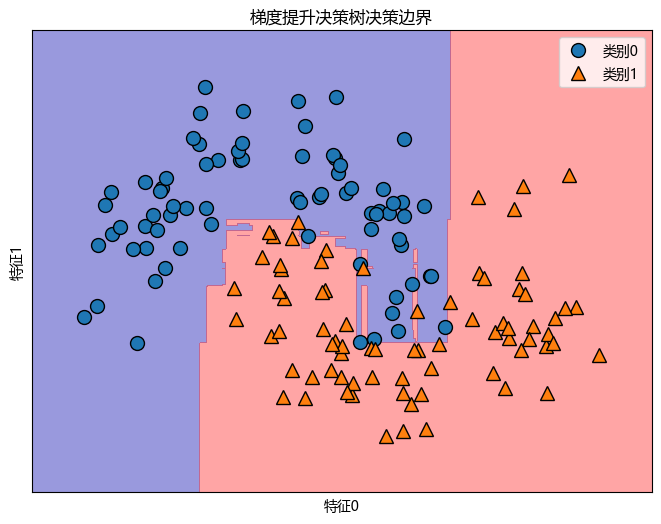

In [19]:
from sklearn.datasets import make_moons

X_moons,y_moons = make_moons(n_samples=200,noise=0.25,random_state=42)

X_train_m,X_test_m,y_train_m,y_test_m = train_test_split(
    X_moons,y_moons,random_state=42
)

gbrt_moons = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gbrt_moons.fit(X_train_m,y_train_m)

print("="*50)
print("半月形数据集上的梯度提升")
print("="*50)
print(f"训练集精度:{gbrt_moons.score(X_train_m,y_train_m):.3f}")
print(f"测试集精度:{gbrt_moons.score(X_test_m,y_test_m):.3f}")

plt.figure(figsize=(8,6))
mglearn.plots.plot_2d_separator(gbrt_moons,X_train_m,fill=True,alpha=0.4)
mglearn.discrete_scatter(X_train_m[:,0],X_train_m[:,1],y_train_m)
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.title("梯度提升决策树决策边界")
plt.legend(["类别0","类别1"],loc="best")
plt.show()